Num GPUs Available:  2
Using GPU: /device:GPU:0

Loading datasets...


I0000 00:00:1775071930.368464      55 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775071930.371423      55 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1775071930.384703      55 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775071930.386134      55 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 58954 files belonging to 6 classes.
Using 47164 files for training.


I0000 00:00:1775072009.588020      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775072009.589441      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 58954 files belonging to 6 classes.
Using 11790 files for validation.
Classes found: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']


...


Starting Training...
Epoch 1/10


I0000 00:00:1775072028.502281     139 service.cc:152] XLA service 0x7dc9d8004d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775072028.502320     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775072028.502325     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775072028.919469     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.2626 - loss: 1.7225

I0000 00:00:1775072033.507547     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


185/185 ━━━━━━━━━━━━━━━━━━━━ 118s 603ms/step - accuracy: 0.8487 - loss: 0.4126 - val_accuracy: 0.9973 - val_loss: 0.0136
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9973 - loss: 0.0122 - val_accuracy: 0.9979 - val_loss: 0.0078
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9982 - loss: 0.0065 - val_accuracy: 0.9981 - val_loss: 0.0074
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9982 - loss: 0.0062 - val_accuracy: 0.9969 - val_loss: 0.0108
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9974 - loss: 0.0076 - val_accuracy: 0.9986 - val_loss: 0.0049
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9993 - loss: 0.0022 - val_accuracy: 0.9979 - val_loss: 0.0094
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9992 - loss: 0.0028 - val_accuracy: 0.9986 - val_loss: 0.0052
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9992 - loss: 0.0023 - val_accuracy: 0.

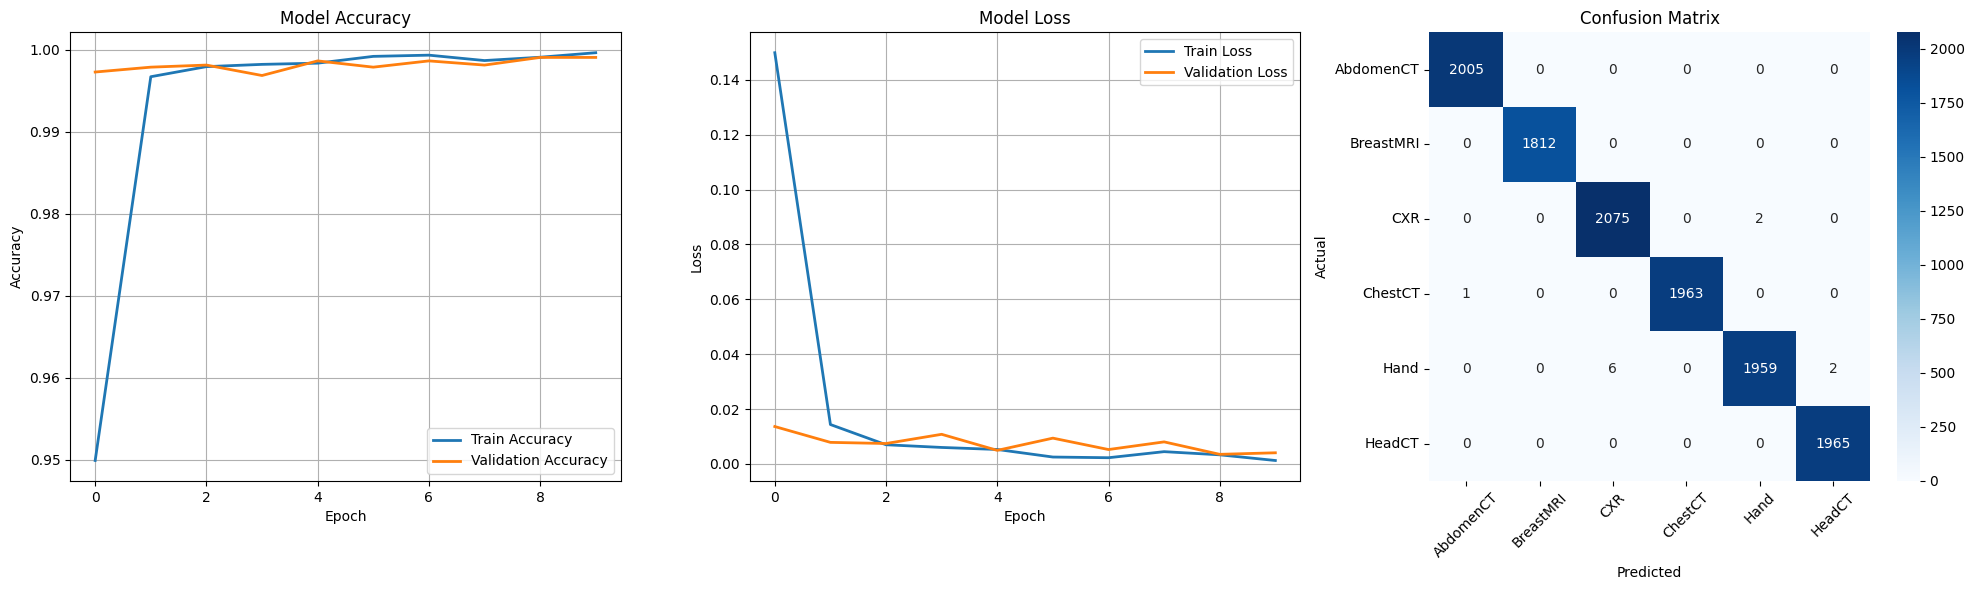


Model successfully saved as 'medical_mnist_cnn_model.keras'

--------- TESTING ON 10 RANDOM IMAGES ---------


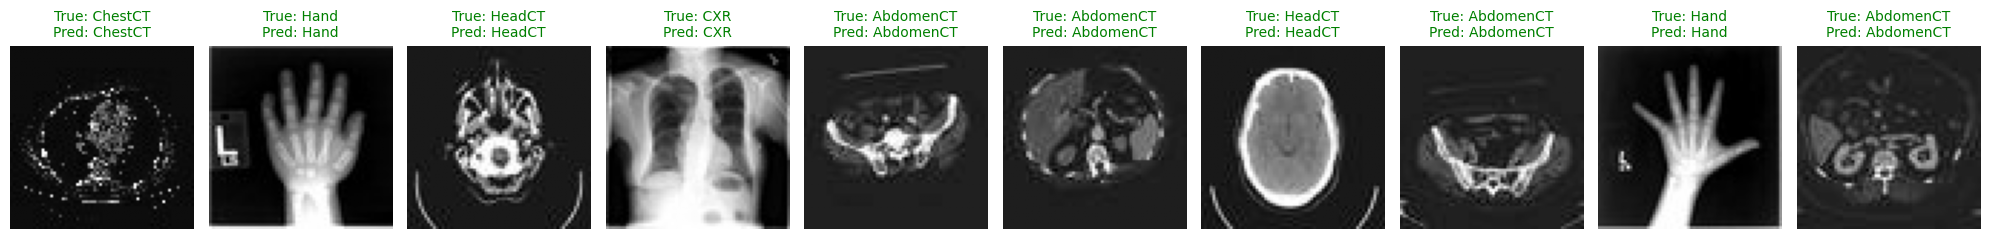

In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. SETUP & HARDWARE CONFIGURATION
# ==========================================
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.test.gpu_device_name():
    print(f"Using GPU: {tf.test.gpu_device_name()}")

# Big batch size for T4 GPU and standard Medical MNIST image dimensions
BATCH_SIZE = 256
IMG_SIZE = (64, 64)
EPOCHS = 10

# Handle Kaggle dataset path variations
data_dir = '/kaggle/input/medical-mnist'
if not os.path.exists(data_dir):
    # Fallback to the exact path structure from your prompt
    data_dir = '/kaggle/input/datasets/andrewmvd/medical-mnist'

# ==========================================
# 2. DATA LOADING & PREPROCESSING
# ==========================================
print("\nLoading datasets...")
# Using grayscale as Medical MNIST images are natively 1-channel
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode="grayscale"
)

class_names = train_ds.class_names
print(f"Classes found: {class_names}")

# Normalize pixel values to be between 0 and 1
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Cache and prefetch for faster GPU feeding
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 3. CNN MODEL ARCHITECTURE
# ==========================================
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Prevent overfitting
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. TRAINING THE MODEL
# ==========================================
print("\nStarting Training...")
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# ==========================================
# 5. EVALUATION, METRICS & CONFUSION MATRIX
# ==========================================
print("\nExtracting Validation Predictions...")
y_true = []
y_pred_probs = []

# Iterate through validation dataset to get true labels and predictions
for images, labels in val_ds.unbatch().batch(BATCH_SIZE):
    y_true.extend(labels.numpy())
    y_pred_probs.extend(model.predict(images, verbose=0))

y_pred = np.argmax(y_pred_probs, axis=1)

# Print Final Accuracy
loss, accuracy = model.evaluate(val_ds, verbose=0)
print(f"\n=====================================")
print(f" FINAL VALIDATION ACCURACY: {accuracy * 100:.2f}% ")
print(f"=====================================\n")

# Print Classification Report
print("--------- CLASSIFICATION REPORT ---------")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plotting Curves & Confusion Matrix
plt.figure(figsize=(20, 6))

# Accuracy Curve
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Curve
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Seaborn Confusion Matrix
plt.subplot(1, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================
# 6. SAVE THE MODEL
# ==========================================
model_filename = 'medical_mnist_cnn_model.keras'
model.save(model_filename)
print(f"\nModel successfully saved as '{model_filename}'")

# ==========================================
# 7. TEST ON 10 RANDOM IMAGES
# ==========================================
print("\n--------- TESTING ON 10 RANDOM IMAGES ---------")

# Grab one batch from the validation dataset
for images, labels in val_ds.unbatch().batch(10).take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

# Predict on the 10 samples
sample_preds = np.argmax(model.predict(sample_images, verbose=0), axis=1)

# Plot the 10 images with True and Predicted labels
plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    # Remove the channel dimension for plotting (64, 64, 1) -> (64, 64)
    plt.imshow(sample_images[i].squeeze(), cmap='gray')
    
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[sample_preds[i]]
    
    # Green text if correct, Red text if wrong
    color = 'green' if true_label == pred_label else 'red'
    
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()